In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz
!pip install -q findspark pyspark

In [2]:
import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NASA Log Analysis") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [3]:
from google.colab import files
uploaded = files.upload()

Saving clean_nasa_logs.csv to clean_nasa_logs.csv


In [4]:
df = spark.read.csv("clean_nasa_logs.csv", header=True, inferSchema=True)

In [5]:
print(df.columns)
df.printSchema()
df.show(10, truncate=False)

['host', 'timestamp', 'method', 'url', 'status', 'size']
root
 |-- host: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- status: integer (nullable = true)
 |-- size: integer (nullable = true)

+---------------------------+--------------------------+------+-----------------------------------------------+------+-----+
|host                       |timestamp                 |method|url                                            |status|size |
+---------------------------+--------------------------+------+-----------------------------------------------+------+-----+
|in24.inetnebr.com          |01/Aug/1995:00:00:01 -0400|GET   |/shuttle/missions/sts-68/news/sts-68-mcc-05.txt|200   |1839 |
|uplherc.upl.com            |01/Aug/1995:00:00:07 -0400|GET   |/                                              |304   |0    |
|uplherc.upl.com            |01/Aug/1995:00:00:08 -0400|GET   |/images/ksclogo-medium.

In [6]:
from pyspark.sql.functions import col

df = df.withColumn("status", col("status").cast("int")) \
       .withColumn("size", col("size").cast("int"))

df.printSchema()

root
 |-- host: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- status: integer (nullable = true)
 |-- size: integer (nullable = true)



In [7]:
from pyspark.sql.functions import col

df = df.withColumn("status", col("status").cast("int")) \
       .withColumn("size", col("size").cast("int"))

df.printSchema()

root
 |-- host: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- status: integer (nullable = true)
 |-- size: integer (nullable = true)



In [8]:
from pyspark.sql.functions import to_timestamp, to_date, hour, col

# Convert string timestamp to proper timestamp type
df = df.withColumn(
    "parsed_timestamp",
    to_timestamp(col("timestamp"), "dd/MMM/yyyy:HH:mm:ss Z")
)

# Extract date
df = df.withColumn("date", to_date(col("parsed_timestamp")))

# Extract hour (NOW possible)
df = df.withColumn("hour", hour(col("parsed_timestamp")))

# Check result
df.select("timestamp", "parsed_timestamp", "date", "hour").show(10, truncate=False)

+--------------------------+-------------------+----------+----+
|timestamp                 |parsed_timestamp   |date      |hour|
+--------------------------+-------------------+----------+----+
|01/Aug/1995:00:00:01 -0400|1995-08-01 04:00:01|1995-08-01|4   |
|01/Aug/1995:00:00:07 -0400|1995-08-01 04:00:07|1995-08-01|4   |
|01/Aug/1995:00:00:08 -0400|1995-08-01 04:00:08|1995-08-01|4   |
|01/Aug/1995:00:00:08 -0400|1995-08-01 04:00:08|1995-08-01|4   |
|01/Aug/1995:00:00:08 -0400|1995-08-01 04:00:08|1995-08-01|4   |
|01/Aug/1995:00:00:09 -0400|1995-08-01 04:00:09|1995-08-01|4   |
|01/Aug/1995:00:00:10 -0400|1995-08-01 04:00:10|1995-08-01|4   |
|01/Aug/1995:00:00:10 -0400|1995-08-01 04:00:10|1995-08-01|4   |
|01/Aug/1995:00:00:10 -0400|1995-08-01 04:00:10|1995-08-01|4   |
|01/Aug/1995:00:00:11 -0400|1995-08-01 04:00:11|1995-08-01|4   |
+--------------------------+-------------------+----------+----+
only showing top 10 rows



In [9]:
df.createOrReplaceTempView("nasa_logs")

In [10]:
peak_hours = spark.sql("""
SELECT hour, COUNT(*) AS total_requests
FROM nasa_logs
GROUP BY hour
ORDER BY total_requests DESC
LIMIT 10
""")

peak_hours.show()

+----+--------------+
|hour|total_requests|
+----+--------------+
|  19|        109461|
|  16|        105143|
|  17|        104535|
|  18|        101392|
|  20|         99527|
|  15|         95342|
|  14|         88309|
|  21|         80834|
|  13|         78695|
|  22|         66809|
+----+--------------+



In [11]:
peak_dates = spark.sql("""
SELECT date, COUNT(*) AS total_requests
FROM nasa_logs
GROUP BY date
ORDER BY total_requests DESC
LIMIT 10
""")

peak_dates.show()

+----------+--------------+
|      date|total_requests|
+----------+--------------+
|1995-08-31|         93506|
|1995-08-30|         76520|
|1995-08-29|         66462|
|1995-08-11|         62401|
|1995-08-09|         61745|
|1995-08-10|         61271|
|1995-08-04|         60953|
|1995-08-15|         60197|
|1995-08-14|         59275|
|1995-08-17|         59208|
+----------+--------------+



In [12]:
top_urls = spark.sql("""
SELECT url, COUNT(*) AS hits
FROM nasa_logs
GROUP BY url
ORDER BY hits DESC
LIMIT 10
""")

top_urls.show(truncate=False)

+---------------------------------------+-----+
|url                                    |hits |
+---------------------------------------+-----+
|/images/NASA-logosmall.gif             |97379|
|/images/KSC-logosmall.gif              |75326|
|/images/MOSAIC-logosmall.gif           |67437|
|/images/USA-logosmall.gif              |67057|
|/images/WORLD-logosmall.gif            |66433|
|/images/ksclogo-medium.gif             |62767|
|/ksc.html                              |43673|
|/history/apollo/images/apollo-logo1.gif|37820|
|/images/launch-logo.gif                |35131|
|/                                      |30306|
+---------------------------------------+-----+



In [13]:
avg_size = spark.sql("""
SELECT AVG(size) AS average_response_size
FROM nasa_logs
""")

avg_size.show()

+---------------------+
|average_response_size|
+---------------------+
|    17089.37821138377|
+---------------------+



In [14]:
top_hosts = spark.sql("""
SELECT host, COUNT(*) AS request_count
FROM nasa_logs
GROUP BY host
ORDER BY request_count DESC
LIMIT 10
""")

top_hosts.show(truncate=False)

+--------------------+-------------+
|host                |request_count|
+--------------------+-------------+
|edams.ksc.nasa.gov  |6530         |
|piweba4y.prodigy.com|4846         |
|163.206.89.4        |4791         |
|piweba5y.prodigy.com|4607         |
|piweba3y.prodigy.com|4416         |
|www-d1.proxy.aol.com|3889         |
|www-b2.proxy.aol.com|3534         |
|www-b3.proxy.aol.com|3463         |
|www-c5.proxy.aol.com|3423         |
|www-b5.proxy.aol.com|3411         |
+--------------------+-------------+



In [15]:
method_usage = spark.sql("""
SELECT method, COUNT(*) AS total_requests
FROM nasa_logs
GROUP BY method
ORDER BY total_requests DESC
""")

method_usage.show()

+------+--------------+
|method|total_requests|
+------+--------------+
|   GET|       1565812|
|  HEAD|          3965|
|  POST|           111|
+------+--------------+



In [16]:
method_usage = spark.sql("""
SELECT method, COUNT(*) AS total_requests
FROM nasa_logs
GROUP BY method
ORDER BY total_requests DESC
""")

method_usage.show()

+------+--------------+
|method|total_requests|
+------+--------------+
|   GET|       1565812|
|  HEAD|          3965|
|  POST|           111|
+------+--------------+



In [17]:
largest_files = spark.sql("""
SELECT host, url, size
FROM nasa_logs
ORDER BY size DESC
LIMIT 10
""")

largest_files.show(truncate=False)

+------------------------+-----------------------------------------------+-------+
|host                    |url                                            |size   |
+------------------------+-----------------------------------------------+-------+
|163.205.156.16          |/statistics/1995/Jul/Jul95_reverse_domains.html|3421948|
|sets12.sprl.umich.edu   |/statistics/1995/bkup/Mar95_full.html          |3155499|
|titan.oit.umass.edu     |/statistics/1995/bkup/Mar95_full.html          |3155499|
|grumpy.ksc.nasa.gov     |/statistics/1995/bkup/Mar95_full.html          |3155499|
|igate.nrc.gov           |/statistics/1995/bkup/Mar95_full.html          |3155499|
|piweba1y.prodigy.com    |/statistics/1995/bkup/Mar95_full.html          |3155499|
|cliffy.lfwc.lockheed.com|/statistics/1995/bkup/Mar95_full.html          |3155499|
|133.55.2.210            |/statistics/1995/bkup/Mar95_full.html          |3155499|
|lace.cs.bgu.ac.il       |/statistics/1995/bkup/Mar95_full.html          |3155499|
|163

In [18]:
daily_avg_size = spark.sql("""
SELECT date, AVG(size) AS avg_size_per_day
FROM nasa_logs
GROUP BY date
ORDER BY date
""")

daily_avg_size.show()

+----------+------------------+
|      date|  avg_size_per_day|
+----------+------------------+
|1995-08-01|15570.117631486057|
|1995-08-03|17125.238561002938|
|1995-08-04|18875.757501681623|
|1995-08-05|19111.637073622474|
|1995-08-06|  19449.1935483871|
|1995-08-07|17133.905295442055|
|1995-08-08|17647.311988935948|
|1995-08-09|16153.464458660621|
|1995-08-10|17106.362895986684|
|1995-08-11| 17770.39282680812|
|1995-08-12| 17843.75939727364|
|1995-08-13|19320.973564954682|
|1995-08-14|18422.637469422185|
|1995-08-15| 17280.18507566822|
|1995-08-16|17947.302733673398|
|1995-08-17|17788.827084177814|
|1995-08-18|16076.827393821048|
|1995-08-19|17954.727630735415|
|1995-08-20| 18805.60192943941|
|1995-08-21|16548.765560278556|
+----------+------------------+
only showing top 20 rows



In [20]:
from pyspark.sql.functions import col, count

# Define status_dist: Counts the occurrences of each HTTP status code
status_dist = spark.sql("""
    SELECT status, COUNT(*) AS count
    FROM nasa_logs
    GROUP BY status
    ORDER BY count DESC
""")

# Define errors: Selects requests with HTTP status codes indicating errors (e.g., 4xx or 5xx)
errors = spark.sql("""
    SELECT host, url, status, size
    FROM nasa_logs
    WHERE status >= 400 AND status < 600
""")

peak_hours.toPandas().to_csv("peak_hours.csv", index=False)
peak_dates.toPandas().to_csv("peak_dates.csv", index=False)
top_urls.toPandas().to_csv("top_urls.csv", index=False)
status_dist.toPandas().to_csv("status_distribution.csv", index=False)
avg_size.toPandas().to_csv("average_response_size.csv", index=False)
top_hosts.toPandas().to_csv("top_hosts.csv", index=False)
method_usage.toPandas().to_csv("method_usage.csv", index=False)
errors.toPandas().to_csv("errors.csv", index=False)
largest_files.toPandas().to_csv("largest_files.csv", index=False)
daily_avg_size.toPandas().to_csv("daily_avg_size.csv", index=False)

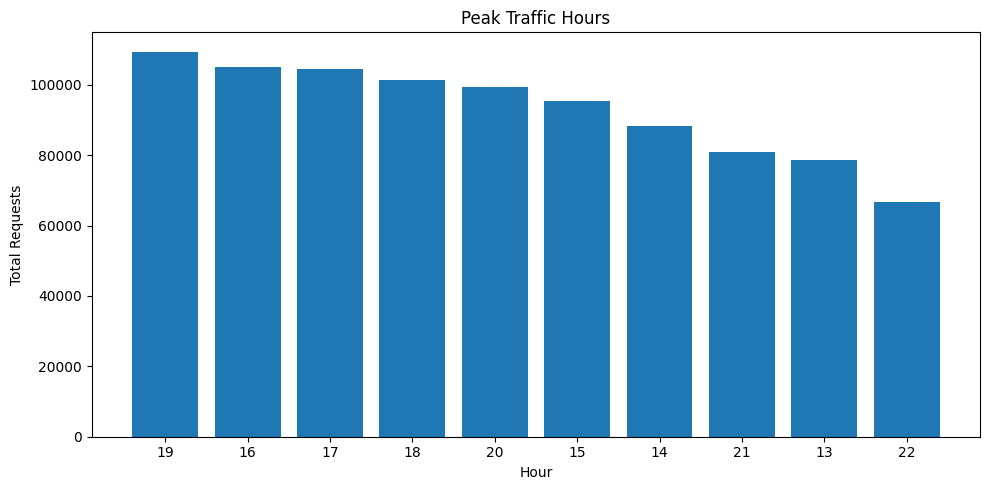

In [21]:
import matplotlib.pyplot as plt

peak_hours_pd = peak_hours.toPandas()

plt.figure(figsize=(10,5))
plt.bar(peak_hours_pd["hour"].astype(str), peak_hours_pd["total_requests"])
plt.title("Peak Traffic Hours")
plt.xlabel("Hour")
plt.ylabel("Total Requests")
plt.tight_layout()
plt.show()

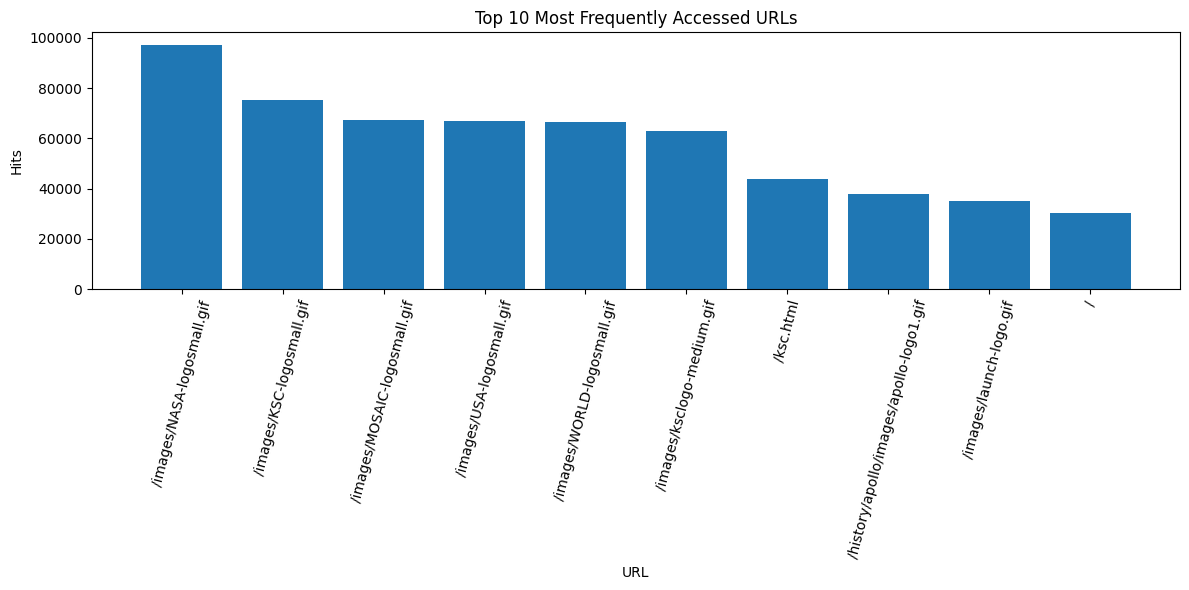

In [22]:
top_urls_pd = top_urls.toPandas()

plt.figure(figsize=(12,6))
plt.bar(top_urls_pd["url"], top_urls_pd["hits"])
plt.xticks(rotation=75)
plt.title("Top 10 Most Frequently Accessed URLs")
plt.xlabel("URL")
plt.ylabel("Hits")
plt.tight_layout()
plt.show()

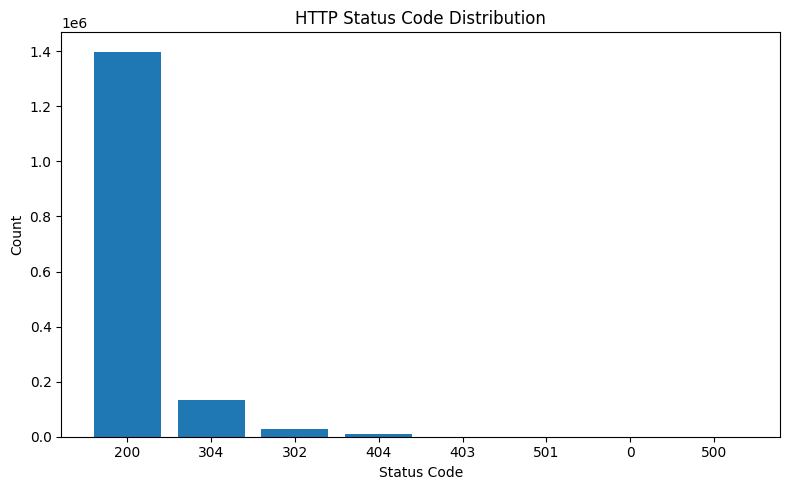

In [24]:
status_pd = status_dist.toPandas()

plt.figure(figsize=(8,5))
plt.bar(status_pd["status"].astype(str), status_pd["count"])
plt.title("HTTP Status Code Distribution")
plt.xlabel("Status Code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

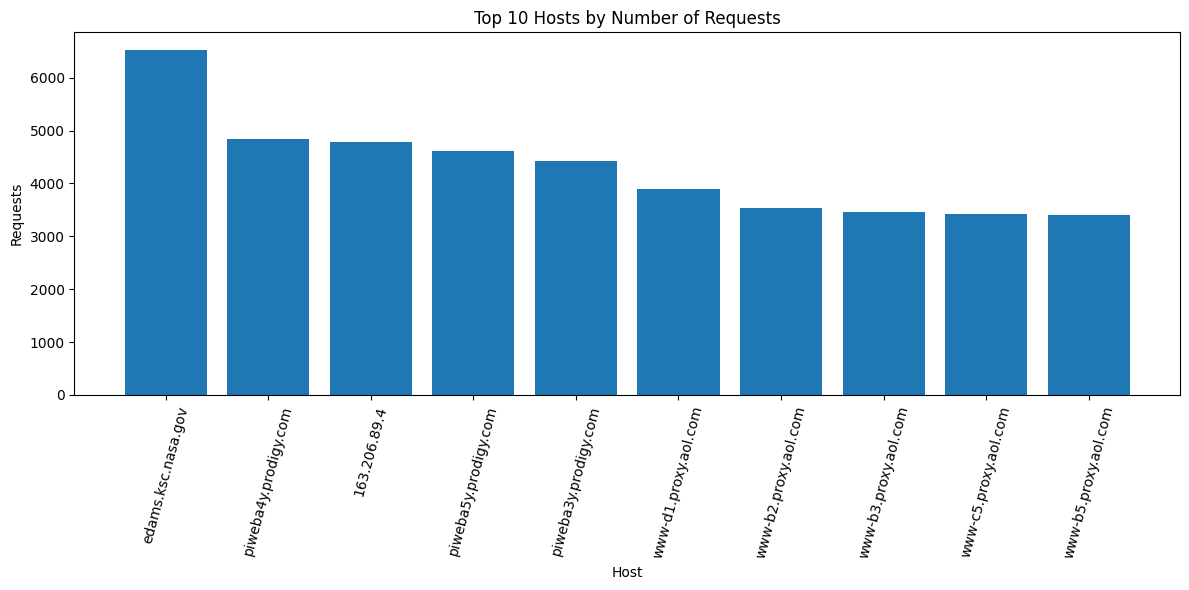

In [25]:
top_hosts_pd = top_hosts.toPandas()

plt.figure(figsize=(12,6))
plt.bar(top_hosts_pd["host"], top_hosts_pd["request_count"])
plt.xticks(rotation=75)
plt.title("Top 10 Hosts by Number of Requests")
plt.xlabel("Host")
plt.ylabel("Requests")
plt.tight_layout()
plt.show()